Objective
This Assignment is regarding the Bike Sharing Demand Prediction Challenge, where your goal is to predict the number of hourly bike rentals, using weather, time, and seasonal data. Through this problem, you will: 
• Learn how to analyze a real-world dataset,
• Apply Linear Regression and its extensions,
• Understand nonlinearity and regularization,
• Evaluate models using a logarithmic error metric (RMSLE).


Target column: count (number of bikes rented per hour)



Import packages and libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Q1. Examine dataset size, missing values, and feature types.

In [2]:
#load csv directly from Google Drive urls
bike_train_dataset = pd.read_csv('https://drive.google.com/uc?export=download&id=18kpPgnoDfOfx3PRRZY3xbsLeWalNViYl')
bike_test_dataset = pd.read_csv('https://drive.google.com/uc?export=download&id=1HJlgPTkGlCzycSTnJNB0oJEfgjSV4o0f')

print(bike_train_dataset.head())
print(bike_test_dataset.head())

print(bike_train_dataset.info())
print(bike_test_dataset.info())

print(bike_train_dataset.describe())
print(bike_test_dataset.describe())

#check for missing values
print(bike_train_dataset.isnull().sum())
print(bike_test_dataset.isnull().sum())





              datetime  season  holiday  workingday  weather      temp  \
0   2012-07-15 7:00:00       3        0           0        1  28.70000   
1  2012-08-14 15:00:00       3        0           1        1  33.62000   
2   2011-02-06 6:00:00       1        0           0        1  10.66000   
3  2012-05-06 17:00:02       2        0           0        2  26.42506   
4   2012-01-09 2:00:00       1        0           1        1   9.84000   

       atemp  humidity  windspeed  casual  registered  count  
0  33.335000        79   6.003200      17          30     47  
1  37.880000        46  15.001300      84         199    283  
2  12.880000        60  15.001300       0           1      1  
3  30.566166        61   9.512288     198         330    531  
4  12.120000        56   8.998100       2           3      5  
           datetime  season  holiday  workingday  weather       temp  \
0   05-06-2012 5:00       2        0           1        3  19.680000   
1  19-03-2011 19:00       1      

Q2. Visualize relationships between key features and the target variable (count).
Q3. Suggest which variables are likely to be most informative.

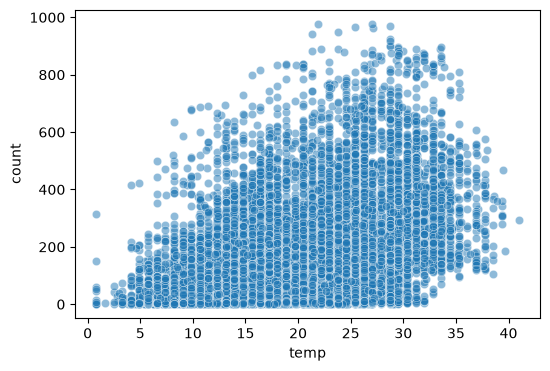

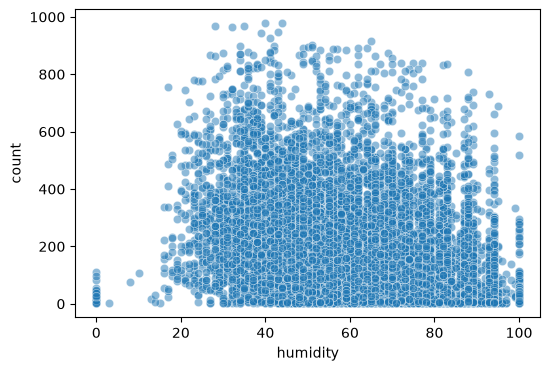

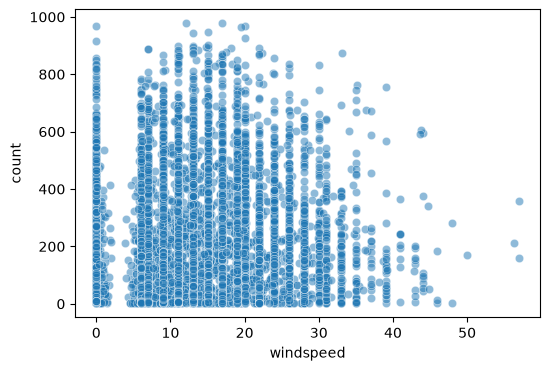

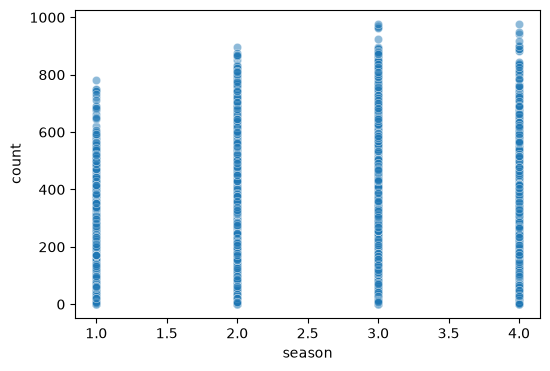

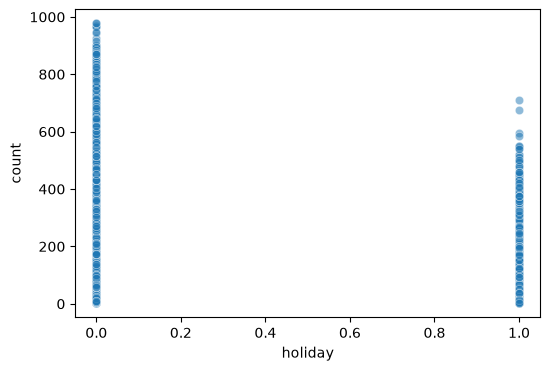

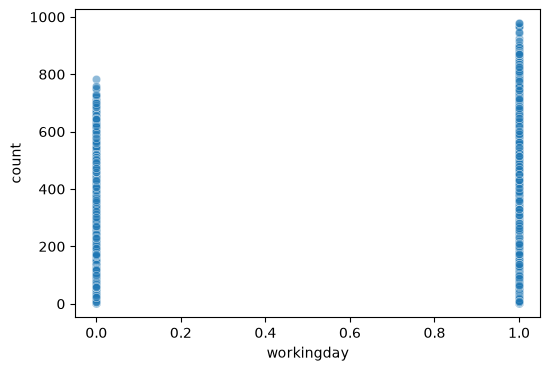

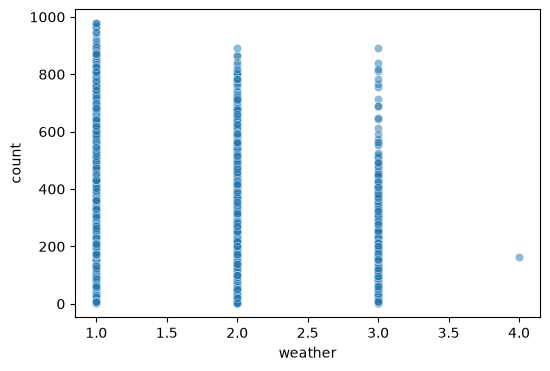

In [3]:
#Visualize relationships between key features and the target variable (count).
plt.figure(figsize=(6,4))
sns.scatterplot(x="temp", y="count", data=bike_train_dataset, alpha=0.5)
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="humidity", y="count", data=bike_train_dataset, alpha=0.5)
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="windspeed", y="count", data=bike_train_dataset, alpha=0.5)
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="season", y="count", data=bike_train_dataset, alpha=0.5)
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="holiday", y="count", data=bike_train_dataset, alpha=0.5)
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="workingday", y="count", data=bike_train_dataset, alpha=0.5)
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="weather", y="count", data=bike_train_dataset, alpha=0.5)
plt.show()


#Our analysis shows that temperature, humidity, and windspeed have a noticeable impact on bike rental counts. 
#As temperature increase after a certain temperature 25-30 degrees Celsius, the bike rental count starts to decrease.
#Similarly, lower humildity below 20 and higher than 95 affect bike rental counts negatively.Else it is almost uniform
# Also as windspeed increases bike rental decreases

#Other features I do not see any patternbut coonverting datetime to day , month, and hour might reveal additional insights.
#So answer to which features most significantly impact bike rental counts, temperature, humidity, and windspeed are key factors.

You can try to derive features from datetime (hour, weekday, month, season), encode categorical variables, consider transformations to capture nonlinear trends to improve your model performance. If you do any of these, report it as answer to Q4. It is optional.

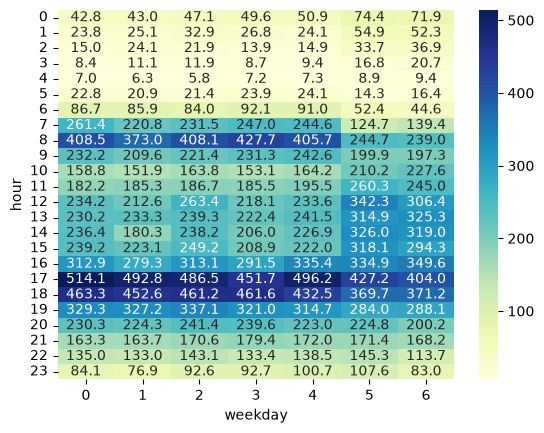

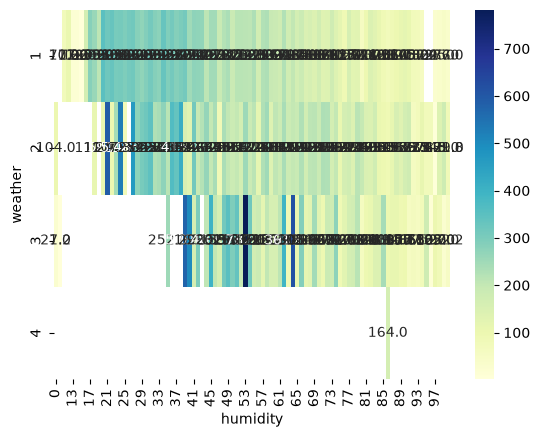

Categorical Features
season
weather
holiday
workingday
weekday
month
year


In [4]:
# Convert datetime to calendar features
bike_train_dataset["datetime"] = pd.to_datetime(
    bike_train_dataset["datetime"], format="mixed", dayfirst=True
)
bike_train_dataset["day"] = bike_train_dataset["datetime"].dt.day
bike_train_dataset["month"] = bike_train_dataset["datetime"].dt.month
bike_train_dataset["hour"] = bike_train_dataset["datetime"].dt.hour
bike_train_dataset["weekday"] = bike_train_dataset["datetime"].dt.dayofweek
bike_train_dataset["year"] = bike_train_dataset["datetime"].dt.year
#heatmap on hour weekday with count will give good information on trend of bike rentals
hourly_weekday_avg = bike_train_dataset.groupby(["hour", "weekday"])["count"].mean().unstack()
weather_humidity_avg = bike_train_dataset.groupby(["weather", "humidity"])["count"].mean().unstack()

sns.heatmap(hourly_weekday_avg, cmap="YlGnBu", annot=True, fmt=".1f")
plt.show()
sns.heatmap(weather_humidity_avg, cmap="YlGnBu", annot=True, fmt=".1f")
plt.show()

categorical_features = [
    "season", "weather", "holiday", "workingday", "weekday", "month", "year"
]
print(f"Categorical Features")
for feature in categorical_features:
    print(f"{feature}")

In [5]:
def rmsle(y_true, y_pred):
    y_pred = np.maximum(0, y_pred)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

Q5. Split data into training and validation sets and build a simple Linear Regression model.
Q6. To improve model performance, you may try to:
•	Extend feature space using polynomial transformations (degree 2 or 3)
•	Apply Ridge and Lasso regression on polynomial features, Tune the regularization strength (α).


Import sklearn and other package to build regresion model

In [6]:
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [7]:
feature_columns = [
    "season", "holiday", "workingday", "weather",
    "temp", "humidity", "windspeed",
    "hour", "weekday", "month", "year"
]

def linear_regression_model(X_train,y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

In [8]:
def polynomial_features_transformation(X_train, X_valid, degree=2):
    polynomial_transfromer = PolynomialFeatures(degree=degree,include_bias=False)
    X_train_poly = polynomial_transfromer.fit_transform(X_train)
    X_valid_poly = polynomial_transfromer.transform(X_valid)
    return X_train_poly,X_valid_poly,polynomial_transfromer

•	Apply Ridge and Lasso regression on polynomial features, Tune the regularization strength (α).

In [9]:
def ridge_lasso_regression_model(X_train_poly, y_train):
    alphas = [0.001, 0.01, 0.1, 1, 10, 100]
    #Feature scaling so that values are withing range of 0 to 1 for features with large values
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_poly)

    ridge = RidgeCV(alphas=alphas, scoring="neg_mean_squared_error", cv=5)
    ridge.fit(X_train_scaled, y_train)

    lasso = LassoCV(alphas=alphas, cv=5, max_iter=20000)
    lasso.fit(X_train_scaled, y_train)

    return ridge, lasso, scaler

Summarize all results (of different models tried out) in one table (RMSLE, key observations).

In [10]:
def evaluate_models(X, y, test_size=0.2, random_state=42):
    #split data to train and test
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=test_size, random_state=random_state)

    #Linear Regression
    linear_model = linear_regression_model(X_train, y_train)
    linear_predctions = np.expm1(linear_model.predict(X_valid))
    lr_rmlse = rmsle(np.expm1(y_valid),linear_predctions)# Y and Y-hat


    #Polynomial Ridge and Lasso
    X_train_poly, X_valid_poly, polynomial_transformer = polynomial_features_transformation(X_train,X_valid,degree=2)

    ridge, lasso, scaler = ridge_lasso_regression_model(X_train_poly, y_train)
    X_valid_scaled = scaler.transform(X_valid_poly)

    ridge_predictions = np.expm1(ridge.predict(X_valid_scaled))
    lasso_predictions = np.expm1(lasso.predict(X_valid_scaled))

    #calculate rmlse root mean square as defined above for ridge and lasso
    ridge_rmsle = rmsle(np.expm1(y_valid), ridge_predictions)
    lasso_rmsle = rmsle(np.expm1(y_valid), lasso_predictions)

    # Summary table
    results_df = pd.DataFrame({
        "Model": ["Linear Regression", "Polynomial Ridge", "Polynomial Lasso"],
        "Validation RMSLE": [lr_rmlse, ridge_rmsle, lasso_rmsle],
        "Selected alpha": [np.nan, ridge.alpha_, lasso.alpha_]
    })
    
    print(results_df.sort_values("Validation RMSLE").to_string(index=False))
    return lr_rmlse, ridge_rmsle, lasso_rmsle, results_df



In [11]:
# Prepare features and target
X = bike_train_dataset[feature_columns]
y = np.log1p(bike_train_dataset["count"])

# Run evaluation
lr_rmsle, ridge_rmsle, lasso_rmsle, results = evaluate_models(X, y)

            Model  Validation RMSLE  Selected alpha
 Polynomial Lasso          0.865433           0.001
 Polynomial Ridge          0.865635           0.001
Linear Regression          1.019834             NaN


Residual plot for the best validation model

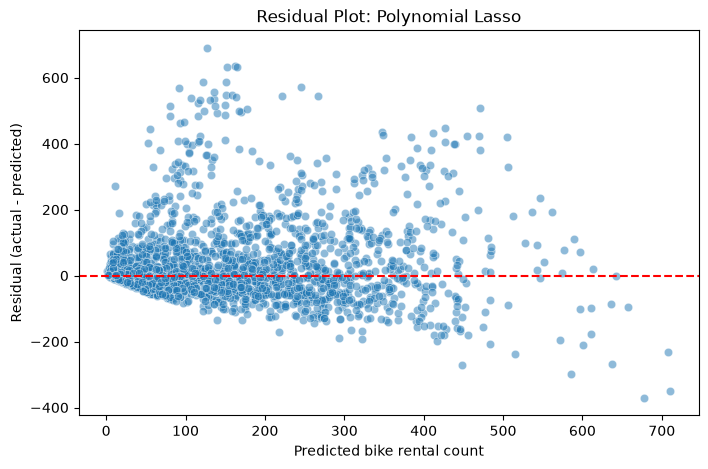

Best model: Polynomial Lasso
Residual mean: 34.2604


In [12]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)
best_model_name = results.loc[results["Validation RMSLE"].idxmin(), "Model"]

if best_model_name == "Linear Regression":
    best_model = linear_regression_model(X_train, y_train)
    best_predictions = np.expm1(best_model.predict(X_valid))
else:
    X_train_poly, X_valid_poly, _ = polynomial_features_transformation(
        X_train, X_valid, degree=2
    )
    best_ridge, best_lasso, best_scaler = ridge_lasso_regression_model(
        X_train_poly, y_train
    )
    X_valid_scaled = best_scaler.transform(X_valid_poly)

    if best_model_name == "Polynomial Ridge":
        best_predictions = np.expm1(best_ridge.predict(X_valid_scaled))
    else:
        best_predictions = np.expm1(best_lasso.predict(X_valid_scaled))

actual_counts = np.expm1(y_valid)
residuals = actual_counts - best_predictions

plt.figure(figsize=(8, 5))
sns.scatterplot(x=best_predictions, y=residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted bike rental count")
plt.ylabel("Residual (actual - predicted)")
plt.title(f"Residual Plot: {best_model_name}")
plt.show()

print("Best model:", best_model_name)
print("Residual mean:", round(residuals.mean(), 4))

Create Submisison.csv using best model and keeping in mind
Required Columns
•	datetime
•	count_predicted
•	Important Requirements
•	The file must contain exactly 2 columns: datetime and count_predicted.
•	Do not rename the columns.
•	Number of rows must exactly match the provided test dataset.
•	Do not modify the datetime format or ordering.
•	count_predicted must contain only numeric values.
•	No missing values or empty cells are allowed.
•	Upload only a .csv file (not Excel or any other format).
•	The submission.csv file should contain predictions generated using your best performing final model.


In [13]:
test_datetime = bike_test_dataset["datetime"].copy()
test_features = bike_test_dataset.copy()
test_features["datetime"] = pd.to_datetime(
    test_features["datetime"], format="mixed", dayfirst=True
)
test_features["month"] = test_features["datetime"].dt.month
test_features["hour"] = test_features["datetime"].dt.hour
test_features["weekday"] = test_features["datetime"].dt.dayofweek
test_features["year"] = test_features["datetime"].dt.year

X_full = bike_train_dataset[feature_columns]
y_full = np.log1p(bike_train_dataset["count"])
X_test = test_features[feature_columns]

model_scores = {
    "Linear Regression": lr_rmsle,
    "Polynomial Ridge": ridge_rmsle,
    "Polynomial Lasso": lasso_rmsle
}
best_model_name = min(model_scores, key=model_scores.get)

if best_model_name == "Linear Regression":
    final_model = linear_regression_model(X_full, y_full)
    count_predicted = np.expm1(final_model.predict(X_test))
else:
    X_full_poly, X_test_poly, final_polynomial_transformer = (
        polynomial_features_transformation(X_full, X_test, degree=2)
    )
    final_ridge, final_lasso, final_scaler = ridge_lasso_regression_model(
        X_full_poly, y_full
    )
    X_test_scaled = final_scaler.transform(X_test_poly)

    if best_model_name == "Polynomial Ridge":
        count_predicted = np.expm1(final_ridge.predict(X_test_scaled))
    else:
        count_predicted = np.expm1(final_lasso.predict(X_test_scaled))

submission = pd.DataFrame({
    "datetime": test_datetime,
    "count_predicted": np.maximum(0, count_predicted)
})

assert len(submission) == len(bike_test_dataset), "Number of rows must exactly match the test dataset!"
assert (submission["datetime"].values == bike_test_dataset["datetime"].values).all(), "Do not modify the datetime format or ordering!"
assert list(submission.columns) == ["datetime", "count_predicted"], "Columns must be exactly ['datetime', 'count_predicted']"
assert submission.notna().all().all(), "Submission must not contain any missing values or empty cells!"

submission.to_csv("submission.csv", index=False)
print("Best model:", best_model_name)
print("Best validation RMSLE:", model_scores[best_model_name])
print("submission.csv created with", len(submission), "rows.")

Best model: Polynomial Lasso
Best validation RMSLE: 0.8654328314670837
submission.csv created with 2613 rows.




Q9. Why does Polynomial Ridge perform best?

It's basically to solve underfitting and overfitting.

Polynomial features let the model capture curved relationships and feature interactions, such as the combined effect of temperature and humidity. Ridge regression also regularizes the larger polynomial feature space, reducing overfitting by shrinking unstable coefficients and reducing overfitting.

Q10. Why does RMSLE treat large-count errors more gently than RMSE?

RMSLE calculates error after applying $\log(1 + x)$. The logarithm compresses large values. RMSE gives big penalties for big counts
That's why we use RMLSE.



Q11. What is the trade-off between simplicity and predictive power?

Linear Regression is simple, fast, and easy to interpret, but it can only represent straight-line relationships between features and the target. Polynomial Ridge adds nonlinear terms and regularization, which generally improves predictive power but makes the model more complex and less interpretable. Lasso can simplify a complex model by setting some coefficients to zero, but overly strong regularization can remove useful information.

Q12. Why can plain Linear Regression not capture time-of-day effects effectively?

Real demand has peaks during morning and evening commute periods and lower demand overnight. These patterns are nonlinear and cyclical: hour 23 is close to hour 0, not far away. Polynomial terms can model curvature, while cyclical sine/cosine features or one-hot encoded hours can model the daily cycle more naturally.